# Data Importing and Preprocessing

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



## 2. Load the Dataset

In [87]:
df= pd.read_csv(r'C:\Users\HP - Victus\OneDrive\Desktop\car_price.csv')
df.head()



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [88]:
df.shape


(72435, 10)

## Task 1:

## 3. Exploratory Data Analysis (EDA)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB


## 4. Determining which features are numerical and Which are categorical

In [90]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Features:",numerical_cols)
print("\nCategorical Features:",categorical_cols)

Numerical Features: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

Categorical Features: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


C:\Users\HP - Victus\AppData\Local\Temp\ipykernel_14032\3944902702.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 5. Checking null values

In [91]:
df.isna().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

## 6.The distribution of car prices 

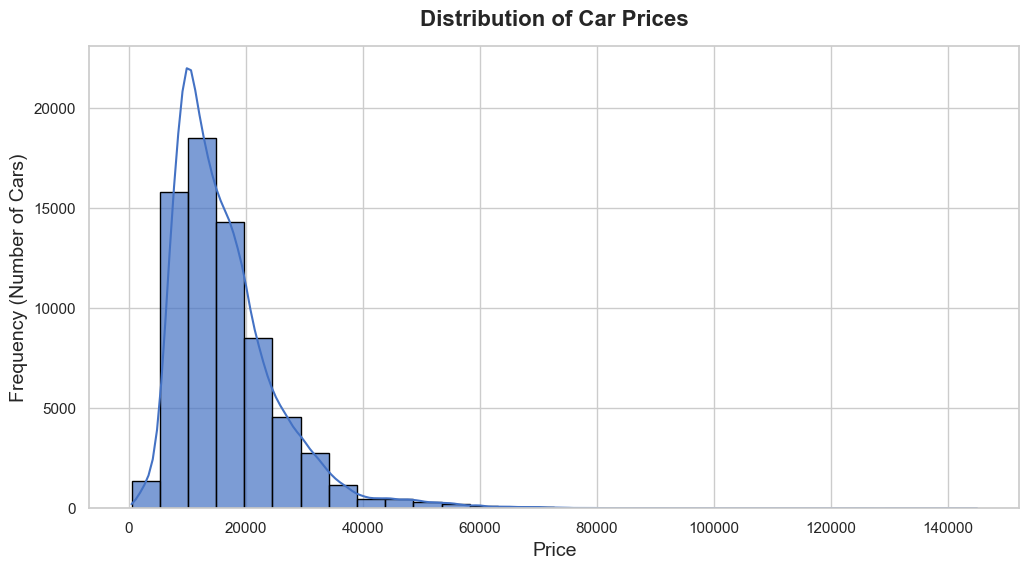

In [92]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(df['price'], bins=30, kde=True, color="#4472c4", edgecolor="black", alpha=0.7)

plt.title('Distribution of Car Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency (Number of Cars)', fontsize=14)

plt.show()

## 7.Which features seem most related to price? 

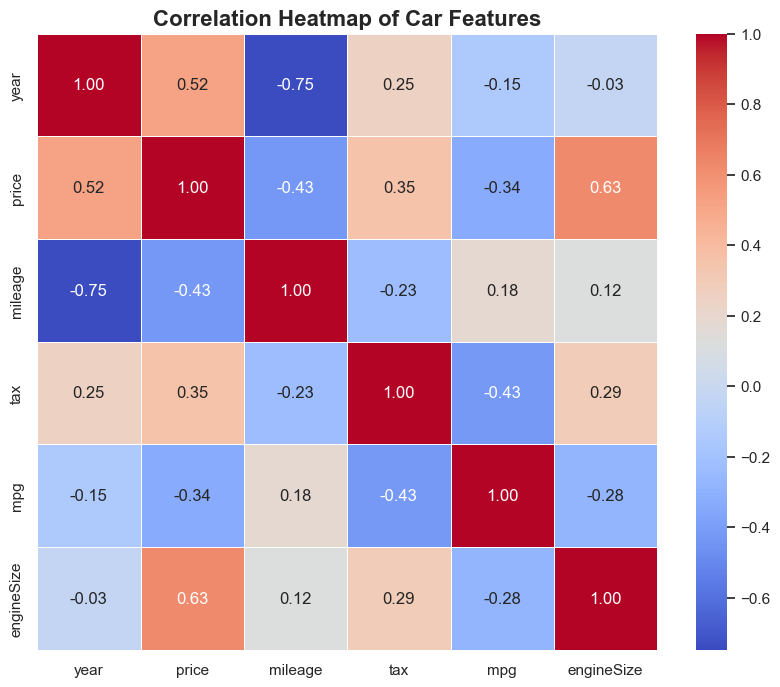

Features most related to price:
price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [93]:

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title('Correlation Heatmap of Car Features', fontsize=16, fontweight='bold')
plt.show()

print("Features most related to price:")
print(correlation_matrix['price'].sort_values(ascending=False))

## Task 2:
## 8.Handle missing values


In [94]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isna().sum())



model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64


C:\Users\HP - Victus\AppData\Local\Temp\ipykernel_14032\4159995913.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## 9.Encode categorical columns



In [95]:
categorical_cols = ['Make', 'model', 'transmission', 'fuelType']
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_data = enc.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=enc.get_feature_names_out(categorical_cols))
df = df.drop(categorical_cols, axis=1)
df = pd.concat([df, encoded_df], axis=1)
df.head()



,year,price,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,model_ i8,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017.0,12500.0,15735.0,150.0,55.4,1.4,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2016.0,16500.0,36203.0,20.0,64.2,2.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2016.0,11000.0,29946.0,30.0,55.4,1.4,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2017.0,16800.0,25952.0,145.0,67.3,2.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2019.0,17300.0,1998.0,145.0,49.6,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 10.scaling numerical features

In [101]:
num_cols = ['year', 'engineSize','mpg','tax','mileage']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()


,year,price,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,model_ i8,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,-0.036052,12500.0,-0.343586,0.504579,-0.024954,-0.426627,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.524724,16500.0,0.638405,-1.566868,0.504773,0.669144,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.524724,11000.0,0.338213,-1.407526,-0.024954,-0.426627,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.036052,16800.0,0.146594,0.424908,0.691382,0.669144,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.941290,17300.0,-1.002645,0.424908,-0.374092,-1.157141,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 11.Detect and handle outliers 

In [ ]:
# --- IQR method 
cols_to_clean = ['price', 'mileage', 'engineSize', 'mpg']

for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"New shape after cleaning outliers: {df.shape}")

New shape after cleaning outliers: (65428, 167)


## Task 3:
## A. Regression Target (Linear Regression)   

,Year,Engine Size,Mileage,Condition,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,0.625610,-0.849254,-0.400662,2,26613.92,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1,0.911720,0.670424,0.001940,0,14679.61,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.196444,0.742790,0.388584,2,44402.61,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.089667,0.453327,-0.946180,2,86374.33,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,-0.375778,-0.632157,0.001940,1,73577.10,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
